In [1]:
# Air Quality Forecasting — Melbourne Microclimate Sensors
## Project 55 | Melbourne Open Playground (MOP)

'''
This notebook explores the Melbourne Microclimate Sensors dataset as part of the Air Quality Forecasting project. The goal is to fuse particulate matter and NO2 sensor networks with short-term weather forecasts to predict air quality hotspots and deliver alerts to vulnerable communities.

This notebook covers:
1. Loading data via the Melbourne Open Data API
2. Exploratory Data Analysis (EDA)
3. Data cleaning and preprocessing
4. Feature engineering
'''
                    

'\nThis notebook explores the Melbourne Microclimate Sensors dataset as part of the Air Quality Forecasting project. The goal is to fuse particulate matter and NO2 sensor networks with short-term weather forecasts to predict air quality hotspots and deliver alerts to vulnerable communities.\n\nThis notebook covers:\n1. Loading data via the Melbourne Open Data API\n2. Exploratory Data Analysis (EDA)\n3. Data cleaning and preprocessing\n4. Feature engineering\n'

In [2]:
## 1. Loading the Dataset
# We access the Microclimate Sensors dataset via the Melbourne Open Data API v2.1.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv('/Users/johnmshaji/Downloads/microclimate-sensors-data.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 591803 rows, 16 columns


,Device_id,Time,SensorLocation,LatLong,MinimumWindDirection,AverageWindDirection,MaximumWindDirection,MinimumWindSpeed,AverageWindSpeed,GustWindSpeed,AirTemperature,RelativeHumidity,AtmosphericPressure,PM25,PM10,Noise
0,ICTMicroclimate-09,2025-11-16T14:47:32+11:00,SkyFarm (Jeff's Shed). Rooftop - Melbourne Con...,"-37.8223306, 144.9521696",0.0,0.0,359.0,0.0,1.1,5.0,18.5,50.000000,999.500000,0.0,0.0,52.500000
1,ICTMicroclimate-03,2025-11-16T15:14:45+11:00,CH1 rooftop,"-37.8140348, 144.96728",187.0,240.0,187.0,0.5,0.8,0.5,18.5,51.500000,994.800000,1.0,4.0,61.100000
2,ICTMicroclimate-05,2025-08-24T04:58:22+10:00,Enterprize Park - Pole ID: COM1667,"-37.8204083, 144.9591192",0.0,0.0,202.0,0.0,0.0,0.5,8.3,88.400000,1024.400000,11.0,13.0,69.000000
3,ICTMicroclimate-01,2025-08-24T04:57:53+10:00,Birrarung Marr Park - Pole 1131,"-37.8185931, 144.9716404",NaN,70.0,NaN,NaN,0.2,NaN,6.5,97.099998,1023.599976,10.0,13.0,51.400002
4,ICTMicroclimate-11,2025-08-24T01:31:41+10:00,1 Treasury Place,"-37.812888, 144.9750857",0.0,0.0,341.0,0.0,0.0,0.8,9.2,75.700000,1021.100000,11.0,17.0,52.300000


In [4]:
## 2. Exploratory Data Analysis
# We begin by understanding the structure of the dataset, including feature names, data types, and missing values.

In [5]:
# Dataset overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 591803 entries, 0 to 591802
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Device_id             591803 non-null  str    
 1   Time                  591803 non-null  str    
 2   SensorLocation        585660 non-null  str    
 3   LatLong               580320 non-null  str    
 4   MinimumWindDirection  529861 non-null  float64
 5   AverageWindDirection  591154 non-null  float64
 6   MaximumWindDirection  529699 non-null  float64
 7   MinimumWindSpeed      529699 non-null  float64
 8   AverageWindSpeed      591152 non-null  float64
 9   GustWindSpeed         529699 non-null  float64
 10  AirTemperature        591152 non-null  float64
 11  RelativeHumidity      591152 non-null  float64
 12  AtmosphericPressure   591152 non-null  float64
 13  PM25                  560416 non-null  float64
 14  PM10                  560416 non-null  float64
 15  Noise      

In [6]:
# Missing values per feature
print("Missing values per feature:")
df.isnull().sum()

Missing values per feature:


Device_id                   0
Time                        0
SensorLocation           6143
LatLong                 11483
MinimumWindDirection    61942
AverageWindDirection      649
MaximumWindDirection    62104
MinimumWindSpeed        62104
AverageWindSpeed          651
GustWindSpeed           62104
AirTemperature            651
RelativeHumidity          651
AtmosphericPressure       651
PM25                    31387
PM10                    31387
Noise                   31387
dtype: int64

In [7]:
# Statistical summary
df.describe()

,MinimumWindDirection,AverageWindDirection,MaximumWindDirection,MinimumWindSpeed,AverageWindSpeed,GustWindSpeed,AirTemperature,RelativeHumidity,AtmosphericPressure,PM25,PM10,Noise
count,529861.000000,591154.000000,529699.000000,529699.000000,591152.000000,529699.000000,591152.000000,591152.000000,591152.000000,560416.000000,560416.000000,560416.000000
mean,21.317389,167.989089,302.216649,3.274437,1.054025,3.421869,16.296348,66.278247,1005.244813,14.809222,7.514734,66.516996
std,58.592947,125.549115,92.985136,31.553855,0.991356,2.617153,5.921106,18.152886,88.420734,96.896282,11.455300,12.351615
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.800000,4.000000,20.900000,0.000000,0.000000,0.000000
25%,0.000000,44.000000,292.000000,0.000000,0.400000,1.500000,12.200000,54.700001,1007.700000,1.000000,3.000000,59.000000
50%,0.000000,161.000000,353.000000,0.000000,0.800000,2.800000,15.700000,67.900000,1013.400000,3.000000,5.000000,68.000000
75%,0.000000,304.000000,358.000000,0.200000,1.500000,4.800000,19.500000,79.300000,1019.100000,6.000000,8.000000,72.100000
max,359.000000,359.000000,360.000000,359.000000,11.200000,52.500000,45.400002,99.800003,1042.900000,1030.700000,429.000000,131.100000


In [8]:
## 3. Data Cleaning
# Several features contain missing values. We use median imputation as the dataset contains significant outliers (e.g. PM2.5 mean of 14.8 but max of 1030.7), making median more robust than mean.

In [9]:
# Median imputation for numeric columns
for column in df.columns:
    if df[column].isnull().sum() > 0:
        if df[column].dtype in ['int64', 'float64']:
            median_val = df[column].median()
            df[column] = df[column].fillna(median_val)
            print(f"{column}: filled with median = {median_val}")

MinimumWindDirection: filled with median = 0.0
AverageWindDirection: filled with median = 161.0
MaximumWindDirection: filled with median = 353.0
MinimumWindSpeed: filled with median = 0.0
AverageWindSpeed: filled with median = 0.8
GustWindSpeed: filled with median = 2.8
AirTemperature: filled with median = 15.7
RelativeHumidity: filled with median = 67.9
AtmosphericPressure: filled with median = 1013.4
PM25: filled with median = 3.0
PM10: filled with median = 5.0
Noise: filled with median = 68.0


In [10]:
## 4. Air Quality Analysis — PM2.5 and PM10
# PM2.5 and PM10 are the primary air quality indicators in this dataset. We examine their distributions and correlation.

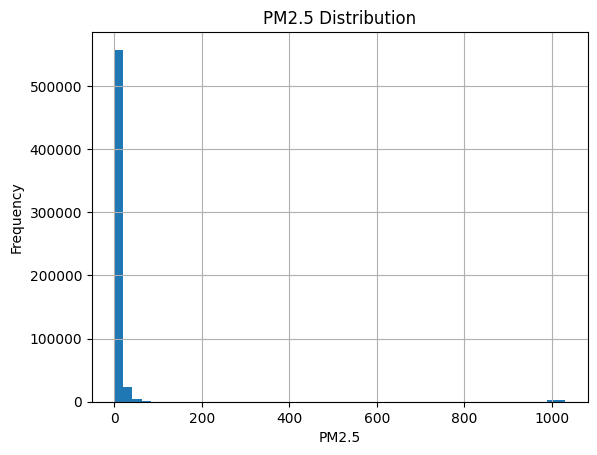

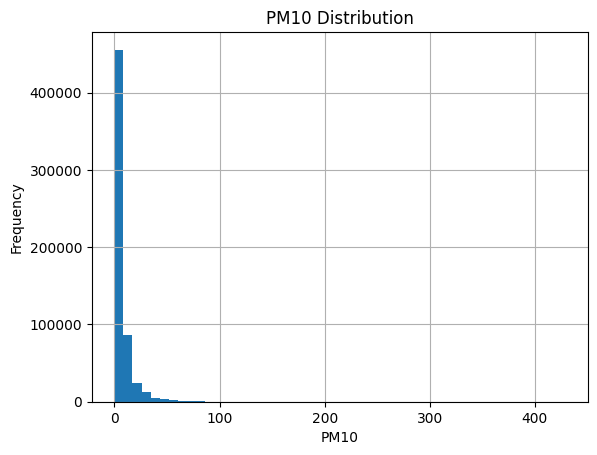

In [11]:
# PM2.5 distribution
df['PM25'].hist(bins=50)
plt.title('PM2.5 Distribution')
plt.xlabel('PM2.5')
plt.ylabel('Frequency')
plt.show()

# PM10 distribution
df['PM10'].hist(bins=50)
plt.title('PM10 Distribution')
plt.xlabel('PM10')
plt.ylabel('Frequency')
plt.show()

In [12]:
#Both PM2.5 and PM10 show heavily right-skewed distributions with most values clustered at low levels and a small number of extreme outliers. This confirms the use of median imputation was appropriate.

In [13]:
# Correlation between PM2.5 and PM10
correlation = df['PM25'].corr(df['PM10'])
print(f"Correlation between PM2.5 and PM10: {correlation:.4f}")

Correlation between PM2.5 and PM10: 0.0695


In [14]:
## 5. Air Quality by Location
# Which sensor locations record the highest PM2.5 levels? This helps identify air quality hotspots across Melbourne.

Top 10 locations by average PM2.5:
SensorLocation
1 Treasury Place                                                                    73.098401
101 Collins St L11 Rooftop                                                           7.062309
Swanston St - Tram Stop 13 adjacent Federation Sq & Flinders St Station              6.825317
CH1 rooftop                                                                          6.268695
SkyFarm (Jeff's Shed). Rooftop - Melbourne Conference & Exhibition Centre (MCEC)     6.095220
Enterprize Park - Pole ID: COM1667                                                   5.773948
Batman Park                                                                          5.082820
Tram Stop 7C - Melbourne Tennis Centre Precinct - Rod Laver Arena                    4.771590
Tram Stop 7B - Melbourne Tennis Centre Precinct - Rod Laver Arena                    4.670269
Birrarung Marr Park - Pole 1131                                                      4.580081
Name: PM25

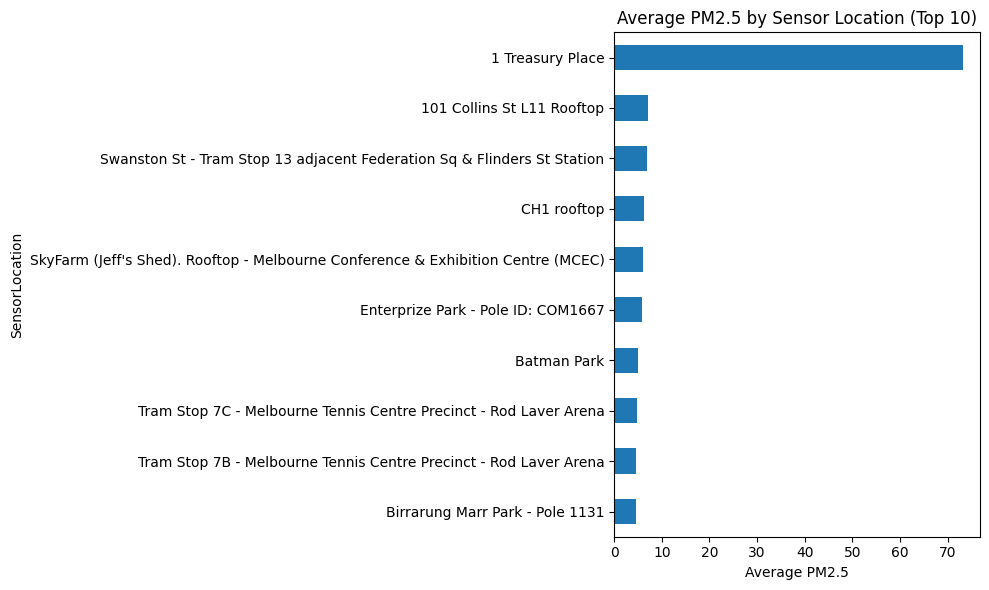

In [15]:
# Average PM2.5 by location
pm25_by_location = df.groupby('SensorLocation')['PM25'].mean().sort_values(ascending=False).head(10)
print("Top 10 locations by average PM2.5:")
print(pm25_by_location)

# Plot
pm25_by_location.plot(kind='barh', figsize=(10, 6))
plt.title('Average PM2.5 by Sensor Location (Top 10)')
plt.xlabel('Average PM2.5')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
## 6. PM2.5 Trends Over Time
# We examine how PM2.5 levels change over time to identify seasonal patterns relevant to forecasting.

/var/folders/tm/wz05rmb92yq_vd4_08gm9zzc0000gn/T/ipykernel_42884/3906039802.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_pm25 = df.groupby(df['Time'].dt.to_period('M'))['PM25'].mean()


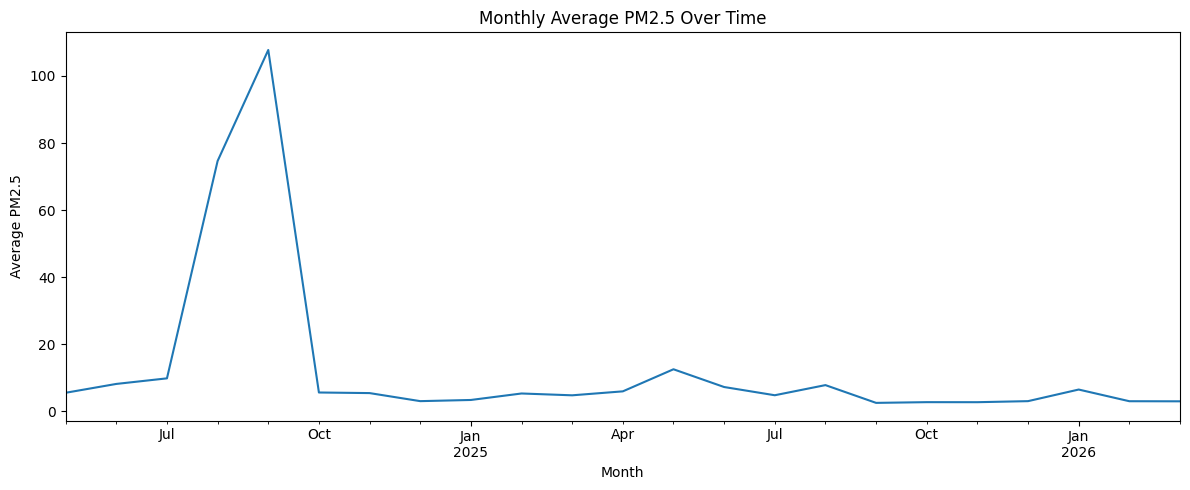

In [17]:
# Convert Time to datetime
df['Time'] = pd.to_datetime(df['Time'], utc=True)

# Monthly average PM2.5
monthly_pm25 = df.groupby(df['Time'].dt.to_period('M'))['PM25'].mean()

monthly_pm25.plot(figsize=(12, 5))
plt.title('Monthly Average PM2.5 Over Time')
plt.xlabel('Month')
plt.ylabel('Average PM2.5')
plt.tight_layout()
plt.show()

In [18]:
## 7. Feature Engineering — Location Encoding and Scaling
# We split the LatLong column into separate Latitude and Longitude features and apply min-max scaling to prepare them for modelling.

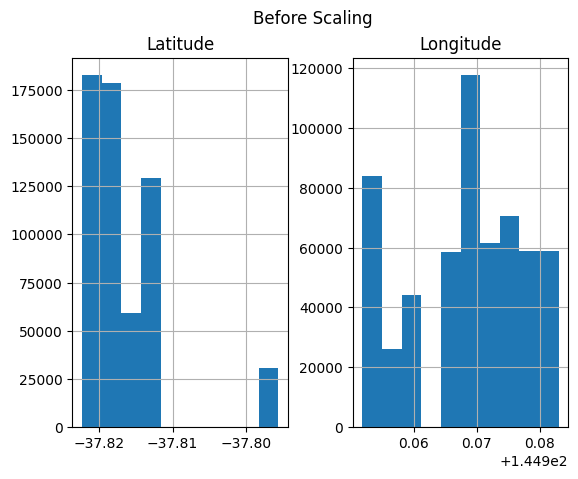

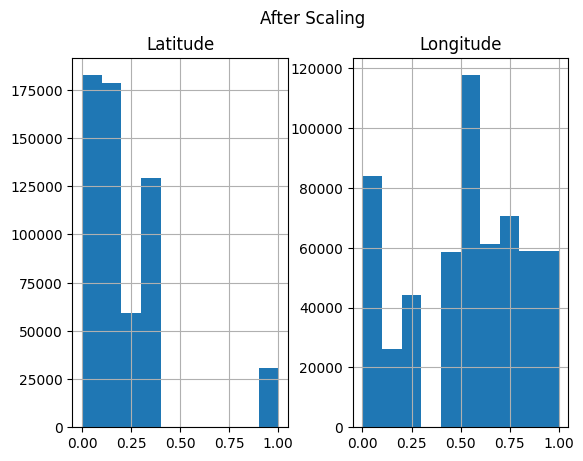

In [19]:
# Split LatLong
df[['Latitude', 'Longitude']] = df['LatLong'].str.split(',', expand=True)
df['Latitude'] = df['Latitude'].astype(float)
df['Longitude'] = df['Longitude'].astype(float)

# Before scaling
df[['Latitude', 'Longitude']].hist()
plt.suptitle('Before Scaling')
plt.show()

# Apply min-max scaling
scaler = MinMaxScaler()
df[['Latitude', 'Longitude']] = scaler.fit_transform(df[['Latitude', 'Longitude']])

# After scaling
df[['Latitude', 'Longitude']].hist()
plt.suptitle('After Scaling')
plt.show()

In [20]:
## 9. Summary and Next Steps

''' 
**Key findings:**
- PM2.5 and PM10 are heavily right-skewed with extreme outliers, requiring robust preprocessing
- PM2.5 and PM10 show weak correlation (0.068), suggesting they are largely independent indicators
- September 2025 recorded the highest average wind speed, which may correlate with lower PM levels
- Certain locations consistently record higher PM2.5 levels, identifying potential air quality hotspots

**Next steps:**
- Engineer additional time-based features (hour of day, day of week, season)
- Investigate relationship between weather variables and PM2.5/PM10 levels
- Select and train a forecasting model (e.g. Random Forest, XGBoost)
- Evaluate model performance and iterate
'''


' \n**Key findings:**\n- PM2.5 and PM10 are heavily right-skewed with extreme outliers, requiring robust preprocessing\n- PM2.5 and PM10 show weak correlation (0.068), suggesting they are largely independent indicators\n- September 2025 recorded the highest average wind speed, which may correlate with lower PM levels\n- Certain locations consistently record higher PM2.5 levels, identifying potential air quality hotspots\n\n**Next steps:**\n- Engineer additional time-based features (hour of day, day of week, season)\n- Investigate relationship between weather variables and PM2.5/PM10 levels\n- Select and train a forecasting model (e.g. Random Forest, XGBoost)\n- Evaluate model performance and iterate\n'